In [1]:
# ============================================================
# ASSIGNMENT 1: STUDENT PERFORMANCE PREDICTION
# Linear Regression
# ============================================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# ============================================================
# LOAD DATASET
# ============================================================

# Dataset file name
file_path = "student_habits_performance.csv"

# Read the CSV file
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# Display the first 5 rows of the dataset

df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.00,1.20,1.10,No,85.00,8.00,Fair,6,Master,Average,8,Yes,56.20
1,S1001,20,Female,6.90,2.80,2.30,No,97.30,4.60,Good,6,High School,Average,8,No,100.00
2,S1002,21,Male,1.40,3.10,1.30,No,94.80,8.00,Poor,1,High School,Poor,1,No,34.30
3,S1003,23,Female,1.00,3.90,1.00,No,71.00,9.20,Poor,4,Master,Good,1,Yes,26.80
4,S1004,19,Female,5.00,4.40,0.50,No,90.90,4.90,Fair,3,Master,Good,1,No,66.40


In [6]:
# Display the last 5 rows of the dataset

df.tail()


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
995,S1995,21,Female,2.60,0.50,1.60,No,77.00,7.50,Fair,2,High School,Good,6,Yes,76.10
996,S1996,17,Female,2.90,1.00,2.40,Yes,86.00,6.80,Poor,1,High School,Average,6,Yes,65.90
997,S1997,20,Male,3.00,2.60,1.30,No,61.90,6.50,Good,5,Bachelor,Good,9,Yes,64.40
998,S1998,24,Male,5.40,4.10,1.10,Yes,100.00,7.60,Fair,0,Bachelor,Average,1,No,69.70
999,S1999,19,Female,4.30,2.90,1.90,No,89.40,7.10,Good,2,Bachelor,Average,8,No,74.90


In [7]:
# ============================================================
# DATASET SHAPE
# ============================================================

rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 1000
Number of columns: 16


In [8]:
# ============================================================
# DATASET INFORMATION
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [9]:
# ============================================================
# DATASET INFORMATION
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [10]:
# ============================================================
# CHECK FOR MISSING VALUES
# ============================================================

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


In [12]:
# ============================================================
# IDENTIFY NUMERIC COLUMNS
# ============================================================

# Select only numeric columns
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numeric columns:")
print(list(numeric_columns))

Numeric columns:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']


In [13]:
# ============================================================
# DEFINE FEATURES (X) AND TARGET (y)
# ============================================================

# Target column
target_column = "exam_score"

# Select all numeric columns except the target
feature_columns = [
    column for column in numeric_columns
    if column != target_column
]

# Features
X = df[feature_columns]

# Target
y = df[target_column]

print("Feature columns:")
print(feature_columns)

print("\nTarget column:")
print(target_column)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Feature columns:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']

Target column:
exam_score

Shape of X: (1000, 8)
Shape of y: (1000,)


In [14]:
# Display the first 5 feature records

print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Features (X):


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating
0,23,0.00,1.20,1.10,85.00,8.00,6,8
1,20,6.90,2.80,2.30,97.30,4.60,6,8
2,21,1.40,3.10,1.30,94.80,8.00,1,1
3,23,1.00,3.90,1.00,71.00,9.20,4,1
4,19,5.00,4.40,0.50,90.90,4.90,3,1



Target (y):


0    56.20
1   100.00
2    34.30
3    26.80
4    66.40
Name: exam_score, dtype: float64

In [16]:
# ============================================================
# CHECK MISSING VALUES IN FEATURES AND TARGET
# ============================================================

print("Missing values in features:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

Missing values in features:
age                      0
study_hours_per_day      0
social_media_hours       0
netflix_hours            0
attendance_percentage    0
sleep_hours              0
exercise_frequency       0
mental_health_rating     0
dtype: int64

Missing values in target:
0


In [17]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

# Split the dataset:
# 80% for training
# 20% for testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (800, 8)
y_train: (800,)

Testing data:
X_test: (200, 8)
y_test: (200,)


In [18]:
# ============================================================
# CREATE LINEAR REGRESSION MODEL
# ============================================================

# Create the Linear Regression model
model = LinearRegression()

print("Linear Regression model created successfully!")

Linear Regression model created successfully!


In [19]:
# ============================================================
# TRAIN THE MODEL
# ============================================================

# Train the Linear Regression model using training data
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [20]:
# ============================================================
# MODEL COEFFICIENTS
# ============================================================

# Create a table showing each feature and its coefficient

coefficients = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,age,0.05
1,study_hours_per_day,9.53
2,social_media_hours,-2.70
3,netflix_hours,-2.32
4,attendance_percentage,0.15
5,sleep_hours,1.99
6,exercise_frequency,1.32
7,mental_health_rating,1.95


In [21]:
# ============================================================
# MODEL INTERCEPT
# ============================================================

print("Model Intercept:", model.intercept_)

Model Intercept: 5.90632417402643


In [22]:
# ============================================================
# MAKE PREDICTIONS
# ============================================================

# Predict exam scores for the test data
y_pred = model.predict(X_test)

print("Predictions generated successfully!")

# Display first 10 predictions
print("\nFirst 10 predicted exam scores:")
print(y_pred[:10])

Predictions generated successfully!

First 10 predicted exam scores:
[66.05204297 74.48132707 78.10484796 74.38034364 61.42454555 54.83488838
 75.91771188 55.42801281 41.61008609 72.81612496]


In [23]:
# ============================================================
# MEAN ABSOLUTE ERROR (MAE)
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 4.1301861490648335


In [24]:
# ============================================================
# MEAN SQUARED ERROR (MSE)
# ============================================================

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 25.92100990901261


In [25]:
# ============================================================
# ROOT MEAN SQUARED ERROR (RMSE)
# ============================================================

rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 5.091268006009172


In [26]:
# ============================================================
# R-SQUARED SCORE
# ============================================================

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.8989154884786842


In [27]:
# ============================================================
# MODEL EVALUATION SUMMARY
# ============================================================

evaluation_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score"
    ],
    "Value": [
        mae,
        mse,
        rmse,
        r2
    ]
})

evaluation_results

,Metric,Value
0,MAE,4.13
1,MSE,25.92
2,RMSE,5.09
3,R² Score,0.90


In [28]:
# ============================================================
# ACTUAL VS PREDICTED EXAM SCORES
# ============================================================

prediction_results = pd.DataFrame({
    "Actual Exam Score": y_test.values,
    "Predicted Exam Score": y_pred
})

# Round predictions to 2 decimal places
prediction_results["Predicted Exam Score"] = (
    prediction_results["Predicted Exam Score"].round(2)
)

prediction_results.head(20)

,Actual Exam Score,Predicted Exam Score
0,64.20,66.05
1,72.70,74.48
2,79.00,78.10
3,79.50,74.38
4,58.20,61.42
5,53.40,54.83
6,70.80,75.92
7,62.50,55.43
8,36.80,41.61
9,67.60,72.82


In [29]:
# ============================================================
# PREDICTION ERROR
# ============================================================

prediction_results["Error"] = (
    prediction_results["Actual Exam Score"] -
    prediction_results["Predicted Exam Score"]
)

prediction_results["Absolute Error"] = (
    prediction_results["Error"].abs()
)

prediction_results.head(20)

,Actual Exam Score,Predicted Exam Score,Error,Absolute Error
0,64.20,66.05,-1.85,1.85
1,72.70,74.48,-1.78,1.78
2,79.00,78.10,0.90,0.90
3,79.50,74.38,5.12,5.12
4,58.20,61.42,-3.22,3.22
5,53.40,54.83,-1.43,1.43
6,70.80,75.92,-5.12,5.12
7,62.50,55.43,7.07,7.07
8,36.80,41.61,-4.81,4.81
9,67.60,72.82,-5.22,5.22


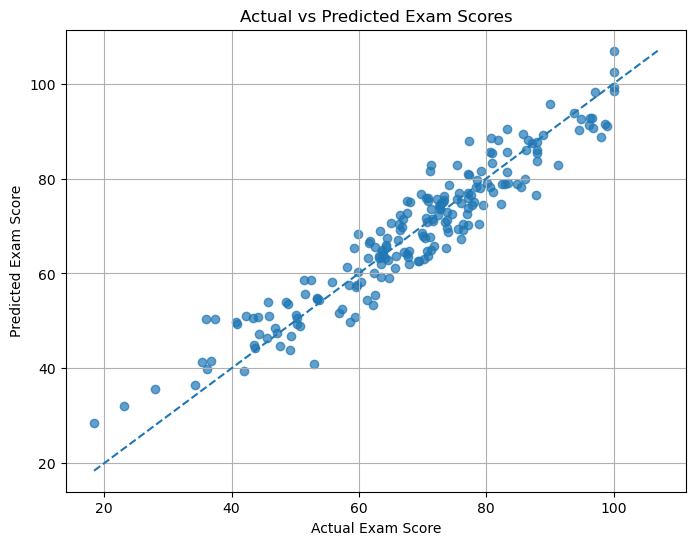

In [30]:
# ============================================================
# ACTUAL VS PREDICTED VALUES
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

plt.grid(True)
plt.show()

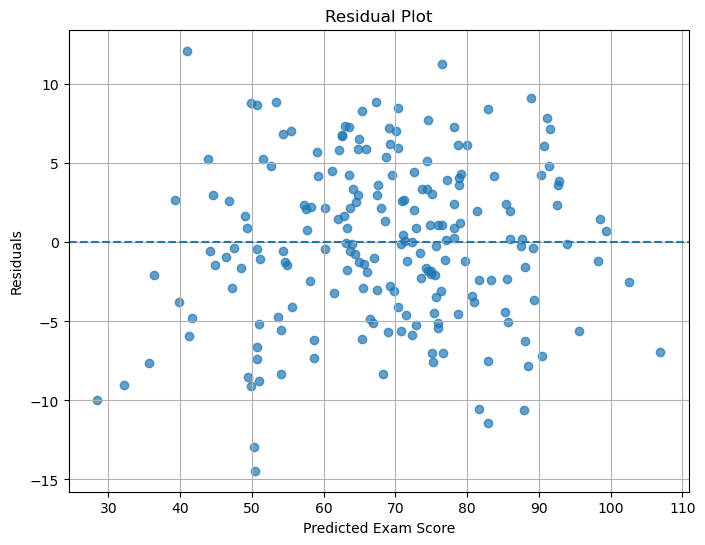

In [31]:
# ============================================================
# RESIDUAL PLOT
# ============================================================

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Exam Score")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)
plt.show()

In [32]:
# ============================================================
# EXAMPLE PREDICTION
# ============================================================

# Take the first student from the test dataset
sample_student = X_test.iloc[[0]]

# Predict exam score
sample_prediction = model.predict(sample_student)[0]

# Get actual score
actual_score = y_test.iloc[0]

print("Student Information:")
display(sample_student)

print("\nActual Exam Score:", round(actual_score, 2))
print("Predicted Exam Score:", round(sample_prediction, 2))

Student Information:


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating
521,23,3.50,2.10,1.40,82.20,7.70,1,3



Actual Exam Score: 64.2
Predicted Exam Score: 66.05


In [33]:
# ============================================================
# PREDICTIONS FOR FIRST 10 TEST STUDENTS
# ============================================================

sample_results = prediction_results.head(10).copy()

sample_results.index = range(1, len(sample_results) + 1)

sample_results

,Actual Exam Score,Predicted Exam Score,Error,Absolute Error
1,64.20,66.05,-1.85,1.85
2,72.70,74.48,-1.78,1.78
3,79.00,78.10,0.90,0.90
4,79.50,74.38,5.12,5.12
5,58.20,61.42,-3.22,3.22
6,53.40,54.83,-1.43,1.43
7,70.80,75.92,-5.12,5.12
8,62.50,55.43,7.07,7.07
9,36.80,41.61,-4.81,4.81
10,67.60,72.82,-5.22,5.22


In [34]:
# ============================================================
# SAVE PREDICTION RESULTS TO CSV
# ============================================================

prediction_results.to_csv(
    "student_exam_score_predictions.csv",
    index=False
)

print("Prediction results saved successfully!")
print("File name: student_exam_score_predictions.csv")

Prediction results saved successfully!
File name: student_exam_score_predictions.csv


In [35]:
# ============================================================
# FINAL MODEL SUMMARY
# ============================================================

print("=" * 60)
print("STUDENT PERFORMANCE PREDICTION - LINEAR REGRESSION")
print("=" * 60)

print("\nTarget Variable:")
print(target_column)

print("\nFeatures Used:")
for feature in feature_columns:
    print("-", feature)

print("\nDataset Size:")
print(len(df), "students")

print("\nTraining Samples:")
print(len(X_train))

print("Testing Samples:")
print(len(X_test))

print("\nMODEL EVALUATION")
print("-" * 60)

print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")

print("\n" + "=" * 60)

STUDENT PERFORMANCE PREDICTION - LINEAR REGRESSION

Target Variable:
exam_score

Features Used:
- age
- study_hours_per_day
- social_media_hours
- netflix_hours
- attendance_percentage
- sleep_hours
- exercise_frequency
- mental_health_rating

Dataset Size:
1000 students

Training Samples:
800
Testing Samples:
200

MODEL EVALUATION
------------------------------------------------------------
MAE      : 4.1302
MSE      : 25.9210
RMSE     : 5.0913
R² Score : 0.8989



In [36]:
# ============================================================
# CONCLUSION
# ============================================================

print("""
CONCLUSION:

A Linear Regression model was successfully applied to the
Student Performance Dataset to predict the Exam Score.

All available numeric columns, except the target column
exam_score, were used as input features.

The dataset was divided into 80% training data and 20%
testing data.

The model was evaluated using:
1. Mean Absolute Error (MAE)
2. Mean Squared Error (MSE)
3. Root Mean Squared Error (RMSE)
4. R² Score

The actual and predicted exam scores were also compared
to evaluate the prediction performance of the model.
""")


CONCLUSION:

A Linear Regression model was successfully applied to the
Student Performance Dataset to predict the Exam Score.

All available numeric columns, except the target column
exam_score, were used as input features.

The dataset was divided into 80% training data and 20%
testing data.

The model was evaluated using:
1. Mean Absolute Error (MAE)
2. Mean Squared Error (MSE)
3. Root Mean Squared Error (RMSE)
4. R² Score

The actual and predicted exam scores were also compared
to evaluate the prediction performance of the model.

